In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import torch
import warnings
from rasterio.errors import NotGeoreferencedWarning

warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

## Potsdam and Vaihingen datasets

In [4]:
## Potsdam
import torchio as tio

from data_module import PotsdamVaihingen, DeadTrees, LoveDAds, GID15, GeoNRW

In [4]:
potsdam_image_glob = "Potsdam_dataset/2_Ortho_RGB/*.tif"
potsdam_mask_glob = "Potsdam_dataset/5_Labels_all/*.tif"
potsdam = PotsdamVaihingen(
    image_glob=potsdam_image_glob, mask_glob=potsdam_mask_glob, to_rgb=True
)

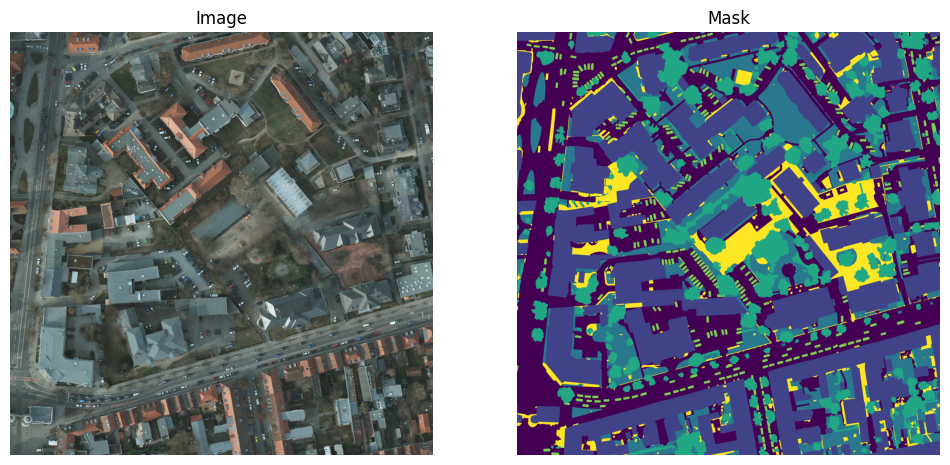

(torch.Size([3, 6000, 6000, 1]), torch.Size([1, 6000, 6000, 1]))

In [ ]:
idx = 13
potsdam.plot(idx, figsize=(12, 6))
potsdam.shape(idx)

In [ ]:
vaihingen_image_glob = "Vaihingen_dataset/top/*.tif"
vaihingen_mask_glob = (
    "Vaihingen_dataset/ISPRS_semantic_labeling_Vaihingen_ground_truth_COMPLETE/*.tif"
)
vaihingen = PotsdamVaihingen(
    image_glob=vaihingen_image_glob, mask_glob=vaihingen_mask_glob, to_rgb=True
)

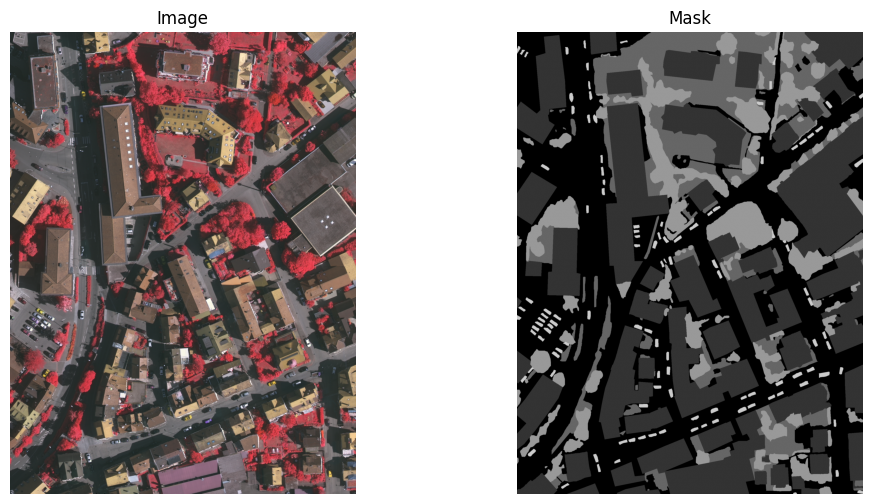

(torch.Size([3, 2569, 1919, 1]), torch.Size([1, 2569, 1919, 1]))

In [ ]:
idx = 0
vaihingen.plot(idx, cmap="gray", figsize=(12, 6))
vaihingen.shape(idx)

## DeadTrees

In [ ]:
image_glob = "Dataset_Templado/dataset_rgb/*"
deadtrees = DeadTrees(image_glob=image_glob, white_threshold=0.1)

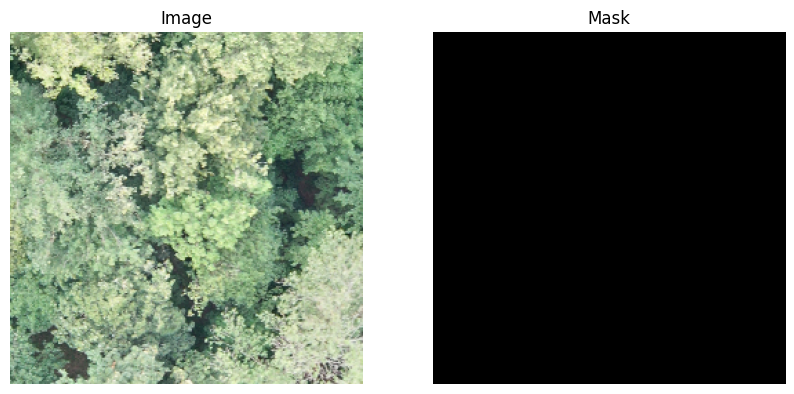

(torch.Size([3, 256, 256, 1]), torch.Size([1, 256, 256, 1]))

In [ ]:
idx = 5421
deadtrees.plot(idx, cmap="gray")
deadtrees.shape(idx)

## LoveDA

In [ ]:
loveda = LoveDAds(root="data", scene=["urban", "rural"])

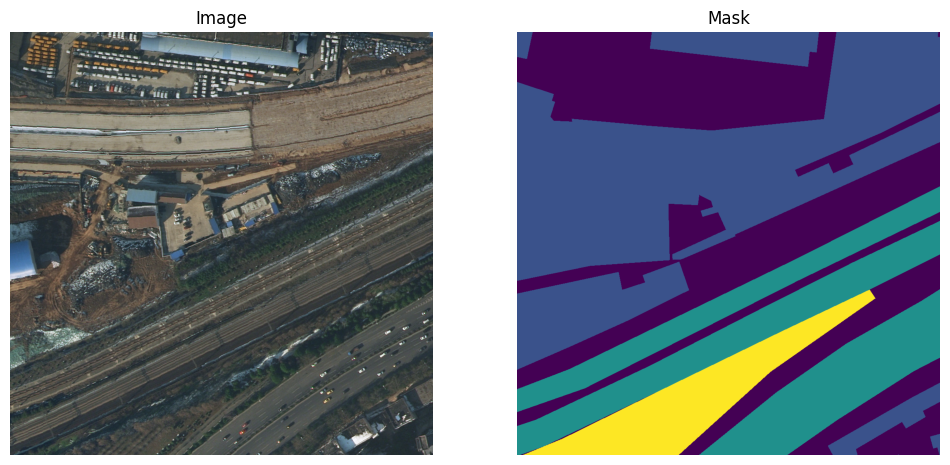

(torch.Size([3, 1024, 1024, 1]), torch.Size([1, 1024, 1024, 1]))

In [ ]:
idx = 2456
loveda.plot(idx, figsize=(12, 6))
loveda.shape(idx)

## GID15

In [5]:
gid15 = GID15(
    image_glob="GID15/gid-15/GID/img_dir/train/*.tif",
    mask_glob="GID15/gid-15/GID/ann_dir/train/*.png",
)

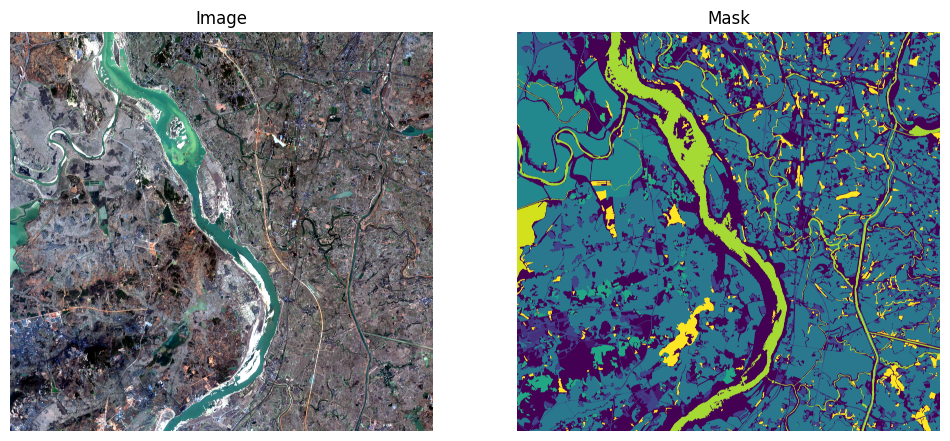

(torch.Size([3, 6800, 7200, 1]), torch.Size([1, 6800, 7200, 1]))

In [ ]:
gid15.plot(0, figsize=(12, 6))
gid15.shape(0)

## GeoNRW

In [ ]:
geonrw = GeoNRW(root="GeoNRW", split="train")

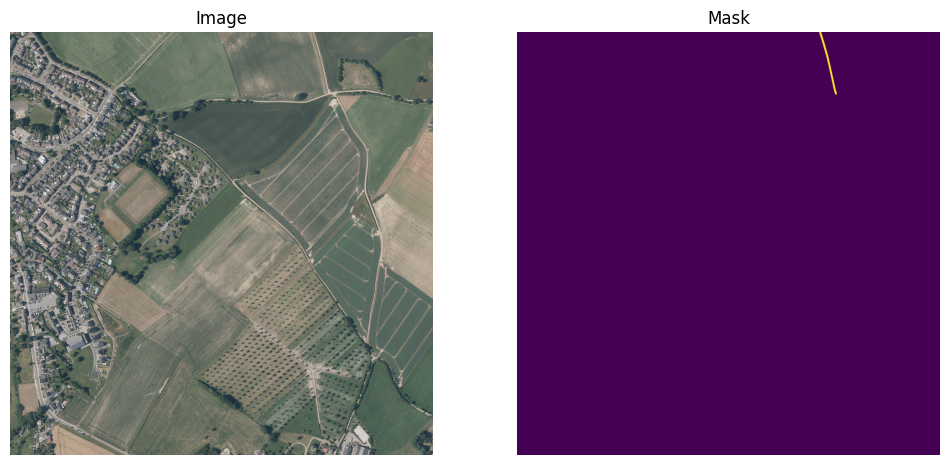

(torch.Size([3, 1000, 1000, 1]), torch.Size([1, 1000, 1000, 1]))

In [ ]:
idx = 0
geonrw.plot(idx, figsize=(12, 15), cmap="viridis", normalized=True)
geonrw.shape(idx)

## Potsdam DataModule

In [8]:
from torch.utils.data import DataLoader


class GridLoader:
    def __init__(self, subjects, patch_size, overlap, batch_size):
        self.subjects = subjects
        self.patch_size = patch_size
        self.overlap = overlap
        self.batch_size = batch_size

    def __iter__(self):
        for subject in self.subjects:
            sampler = tio.GridSampler(
                subject,
                patch_size=self.patch_size,
                patch_overlap=self.overlap,
            )

            loader = DataLoader(
                sampler,
                batch_size=self.batch_size,
                num_workers=0,
            )

            for batch in loader:
                yield batch

In [ ]:
tr_dl = GridLoader(gid15, patch_size=(256, 256, 1), overlap=(0, 0, 0), batch_size=8)

In [13]:
count = 0
for batch in tr_dl:
    print(batch["image"][tio.DATA].shape, batch["mask"][tio.DATA].shape)
    count += 1
    if count == 20:  # Print the first 5 batches
        break

torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Size([8, 1, 256, 256, 1])
torch.Size([8, 3, 256, 256, 1]) torch.Si

In [20]:
from torch.utils.data import Dataset


class GridPatchDataset(Dataset):
    def __init__(self, subjects, patch_size=(256, 256, 1), patch_overlap=(10, 10, 0)):
        self.samplers = [
            tio.data.GridSampler(
                subject, patch_size=patch_size, patch_overlap=patch_overlap
            )
            for subject in subjects
        ]

        # Precompute cumulative lengths for indexing
        self.lengths = [len(s) for s in self.samplers]
        self.cumsum = torch.tensor(self.lengths).cumsum(0)

    def __len__(self):
        return int(self.cumsum[-1])

    def __getitem__(self, idx):
        # Find which sampler this index belongs to
        sampler_idx = torch.searchsorted(self.cumsum, idx).item()

        if sampler_idx == 0:
            local_idx = idx
        else:
            local_idx = idx - self.cumsum[sampler_idx - 1].item()

        return self.samplers[sampler_idx][local_idx]

In [1]:
from data_module import PotsdamVaihingen, DeadTrees, LoveDAds, GID15, GeoNRW

loveda = LoveDAds(
    root="loveda_dataset", split="val", scene=["urban", "rural"], download=True
)

Files already downloaded and verified


In [2]:
output = loveda[0]